# Random Forest
Addestriamo nuovamente un modello come visto per la Logistic Regression usando il metodo delle Random Forests. Interpretiamo la domanda esattamente come espresso per la Logistic Regression.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import datasets
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import metrics

In [2]:
# scelta del seed random per la riproducibilità dei risultati
seed = 12

## Studio binario

Come spiegato nel notebook relativo alla regressione logistica, cominciamo l'analisi studiando una versione binaria del problema. In questo caso poniamo il threshold tra le due categorie di qualità dell'aria a 40, ovvero la soglia tra le categorie 'fair' e 'moderate'. 

In [3]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
binary_class_df = pd.read_csv('../../data/processed/dataset_binary_class_processed.csv')

# togliamo la colonna 'winds_spd'
binary_class_df.drop('winds_spd', axis=1, inplace=True)

# escludiamo poi anche diverse righe contenenti NaN sulle rilevazioni degli inquinanti (probabilmente dovute a malfunzionamenti dei sensori)
binary_class_df.dropna(inplace=True)

binary_class_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,monday,tuesday,wednesday,...,NO2_2,AQI_2,power_area_50_2,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,target
0,1,0,0,0,0,0,0,0,0,0,...,17.0,22.0,14.669913,19.0,19.0,24.0,17.861264,10.950,0.0,1
1,1,0,0,0,0,0,0,0,0,0,...,18.0,26.0,16.969367,20.0,17.0,22.0,14.669913,11.000,0.0,1
2,1,0,0,0,0,0,0,0,0,0,...,16.0,26.0,15.329278,21.0,18.0,26.0,16.969367,10.925,0.0,1
3,1,0,0,0,0,0,0,0,0,0,...,16.0,32.0,17.519438,19.0,16.0,26.0,15.329278,10.950,0.0,1
4,1,0,0,0,0,0,0,0,0,0,...,15.0,22.0,17.446178,24.0,16.0,32.0,17.519438,11.550,0.0,1


### Train, Valid, Test split

Dividiamo quindi il dataset in train (70%), valid (15%) e test (15%). In un primo momento alleniamo il modello su train e usiamo GridSearchCV per trovare gli iperparametri migliori. In seguito ottimizziamo il threshold decisionale su valid. Dopo aver fatto ciò, rialleniamo il modello su test + valid utilizzando gli iperparametri ricavati e adottando alla fine il threshold trovato precedentemente, che consideriamo ancora valido. Infine, testiamo il modello ottenuto su test per ricavare $E_{out}$.

In [4]:
feature_cols = binary_class_df.columns.difference(['target'])

# creiamo train, valid e test
X_train, X_temp, y_train, y_temp = train_test_split(binary_class_df[feature_cols], binary_class_df['target'], test_size=0.3, random_state=seed)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

# riscaliamo le feature numeriche, mettendo la media a 0 e la deviazione std a 1
station_cols = [col for col in X_train.columns if col.startswith('station_')]
non_num_features = ['day', 'hour', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday'] + station_cols
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_valid = scaler.transform(X_valid[num_features])
scaled_num_X_test  = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_valid = X_valid.copy()
scaled_X_test  = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_valid[num_features] = scaled_num_X_valid
scaled_X_test[num_features]  = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,PM10_3,day,...,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,sunday,temperature,thursday,tuesday,wednesday
174,1.501232,1.417956,0.492900,-0.119503,-0.084608,-0.219384,1.122170,0.919681,0.520948,8,...,0,0,0,0,0,0,1.141466,0,0,0
290,1.389393,2.122715,1.700811,0.014473,0.684912,0.783722,1.773956,3.775301,2.632271,13,...,0,0,0,0,0,0,0.905694,0,0,1
8997,-0.188777,-0.065747,0.554844,0.717849,0.383795,0.482790,0.219697,0.318497,0.822566,33,...,0,0,0,0,1,0,-1.967441,0,1,0
4664,-0.891653,-0.830781,-0.784698,-0.722396,-0.820671,-0.888120,-0.883326,-0.833771,-0.886600,26,...,0,1,0,0,0,0,-0.306067,0,1,0
7744,0.121886,0.305179,0.214152,0.650861,0.919113,0.716848,0.019147,0.118103,0.018252,39,...,0,0,0,1,0,0,-0.931138,0,0,0


### Allenamento modello

In [5]:
# creiamo una griglia di iperparametri
param_grid = {'n_estimators': [100, 200, 500],
                'max_depth': [5, 10, None],
                'min_samples_leaf': [1, 2, 5],
                'max_features': [None, 'sqrt', 'log2'],
                'class_weight': [None, 'balanced']}


# inizializziamo il classificatore
rfc_2 = GridSearchCV(RandomForestClassifier(random_state=seed),
                    param_grid,                                                   # iperparametri
                    scoring=metrics.make_scorer(metrics.matthews_corrcoef),       # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
                    cv=5,                                                         # numero di fold della cross validation
                    n_jobs=-1,                                                    # sfruttiamo al massimo la CPU
                    refit=True)                                                   # usiamo i parametri trovati per addestrare il modello su tutto train

In [6]:
# alleniamo e troviamo gli iperparametri migliori
rfc_2.fit(scaled_X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=12), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [5, 10, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5],
                         'n_estimators': [100, 200, 500]},
             scoring=make_scorer(matthews_corrcoef, response_method='predict'))

In [7]:
# qual è la migliore combinazione di iperparametri?
print(rfc_2.best_params_)

{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}


In [8]:
# diamo un'occhiata anche alle altre combinazioni migliori
results_2 = pd.DataFrame(rfc_2.cv_results_)

results_2.sort_values(by='mean_test_score', ascending=False).head()
# notiamo che in tutte le migliori combinazioni class_weight='balanced'

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_max_depth,param_max_features,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
148,2.144619,0.157262,0.048430,0.012384,balanced,None,sqrt,2,200,"{'class_weight': 'balanced', 'max_depth': None...",0.881755,0.828474,0.880140,0.837637,0.865296,0.858660,0.021873,1
147,1.124792,0.106928,0.029279,0.006306,balanced,None,sqrt,2,100,"{'class_weight': 'balanced', 'max_depth': None...",0.872994,0.826121,0.887121,0.839969,0.863277,0.857897,0.022100,2
141,3.438633,0.097050,0.018232,0.000614,balanced,None,None,5,100,"{'class_weight': 'balanced', 'max_depth': None...",0.858583,0.830029,0.887121,0.836858,0.859607,0.854440,0.020085,3
116,18.836672,0.705469,0.075745,0.012214,balanced,10,None,5,500,"{'class_weight': 'balanced', 'max_depth': 10, ...",0.862935,0.830453,0.879323,0.839207,0.857623,0.853908,0.017364,4
143,22.521447,1.201476,0.087442,0.014927,balanced,None,None,5,500,"{'class_weight': 'balanced', 'max_depth': None...",0.862935,0.825716,0.881262,0.839207,0.859263,0.853677,0.019334,5


In [9]:
rfc_2_best = rfc_2.best_estimator_

### Studio importanza features

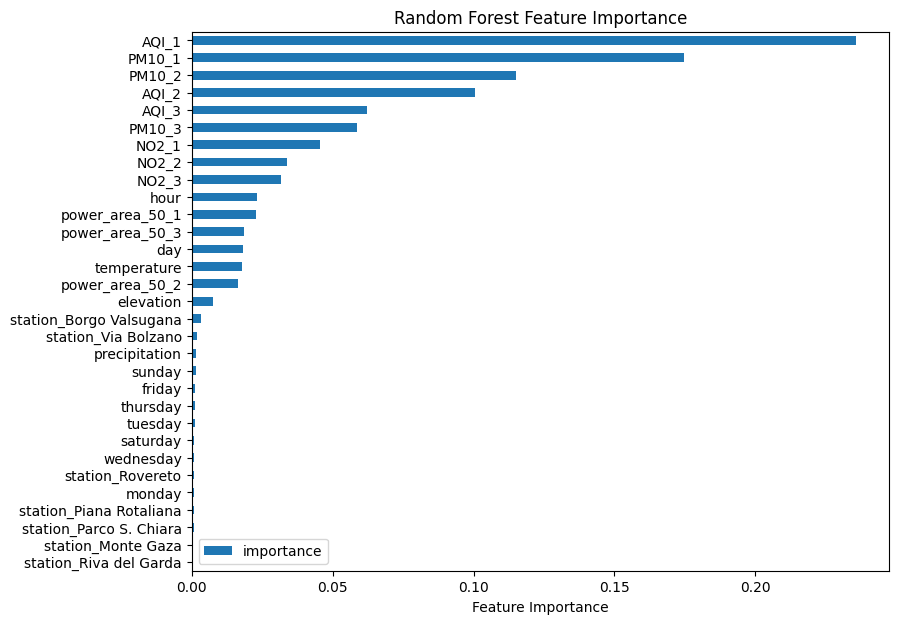

In [10]:
# quali feature sono più importanti?
classification_features = scaled_X_train.columns.difference(['target'])

df_importance_2 = pd.DataFrame({'importance': rfc_2_best.feature_importances_}, index=classification_features)

df_importance_2 = df_importance_2.sort_values(by='importance', ascending=True)

df_importance_2.plot.barh(figsize=(9,7))

plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

Vediamo dall'immagine precedente che i fattori più importanti per il modello sono quelli relativi alle concentrazioni di inquinanti, e qualità dell'aria nelle ore precedenti. Anche potenza elettrica utilizzata, temperatura e orario sono feature rilevanti. D'altro canto, il giorno della settimana, le precipitazioni e la stazione di misurazione sono feature poco utili, che potrebbero probabilmente essere tagliate senza compromettere sensibilmente il modello. 

Questo risultato ci stupisce leggermente poiché si discosta significativamente da quanto visto nel caso della Regressione Logistica, dove la stazione del Monte Gaza era la seconda feature più rilevante.

### Studio matrici di confusione

Studiamo quindi le matrici di confusione per train e valid, in questo modo capiamo come si comporta il nostro modello ed individuiamo un eventuale overfitting.

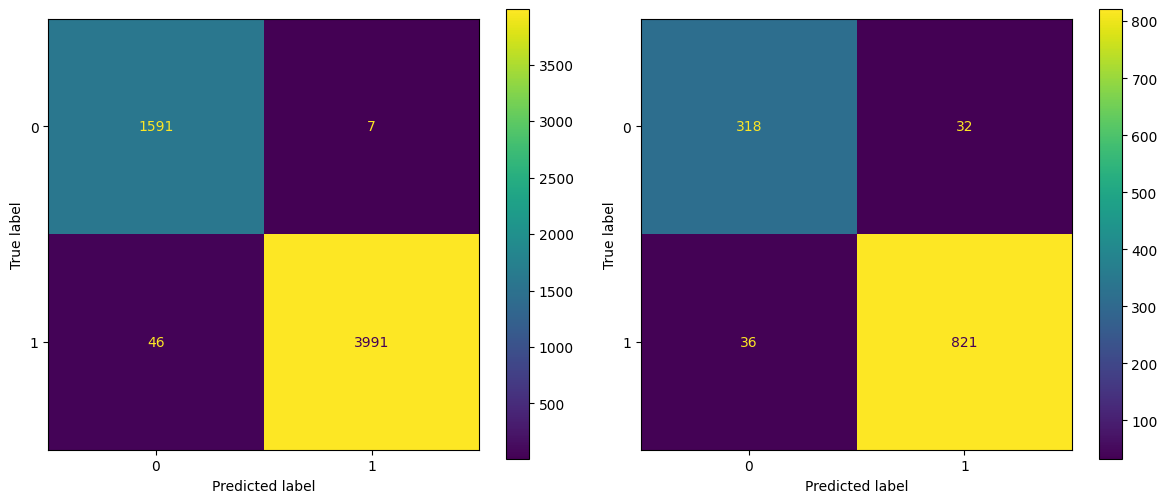

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_pred_tr = rfc_2_best.predict(scaled_X_train)
metrics.ConfusionMatrixDisplay.from_predictions(y_train, y_pred_tr, display_labels=rfc_2_best.classes_, ax = axes[0])

y_pred_va = rfc_2_best.predict(scaled_X_valid)
metrics.ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_va, display_labels=rfc_2_best.classes_, ax = axes[1])

plt.tight_layout()
plt.show()

Non sembra esserci overfitting. Il modello funziona bene anche nell'insieme di validazione anche se, chiaramente, il numero di false classificazioni aumenta all'infuori dell'insieme di training.

### Valutiamo velocemente la performance del modello sul valid

In [12]:
accuracy_score = metrics.accuracy_score(y_valid, y_pred_va)
precision_score = metrics.precision_score(y_valid, y_pred_va)
recall_score = metrics.recall_score(y_valid, y_pred_va)
f1_score = metrics.f1_score(y_valid, y_pred_va)
MCC_score = metrics.matthews_corrcoef(y_valid, y_pred_va)

print(f'Accuratezza: {accuracy_score:.5f}')
print(f'Precisione:  {precision_score:.5f}')
print(f'Recall:      {recall_score:.5f}')
print(f'F1 score:    {f1_score:.5f}')
print(f'MCC:         {MCC_score:.5f}')

Accuratezza: 0.94366
Precisione:  0.96249
Recall:      0.95799
F1 score:    0.96023
MCC:         0.86367


Il modello si conferma buono sotto tutte le metriche principali.

### Ottimizzazione del threshold

In questo caso, omettiamo gli altri metodi visti nel notebook "04_logistic_regression" per ottimizzare il threshold e utilizziamo direttamente il metodo che abbiamo scelto come migliore, ovvero la massimizzazione dell'MCC.

In [13]:
y_proba_va = rfc_2_best.predict_proba(scaled_X_valid)[:, 1]

max_MCC_score = -1
best_thr = None

thr = np.linspace(0, 1, 1001)

for t in thr:
    y_pred = (y_proba_va >= t).astype(int)
    MCC_score = metrics.matthews_corrcoef(y_valid, y_pred)

    if (MCC_score > max_MCC_score):
        max_MCC_score = MCC_score
        best_thr = t


print(f'Threshold MCC: {best_thr:.5f}')
print(f'Massimo MCC:   {max_MCC_score:.5f}')

Threshold MCC: 0.32500
Massimo MCC:   0.87385


Un threshold abbastanza distante dal centro non è inatteso visto lo sbilanciamento delle nostre due classi. Il valore dell'MCC ci soddisfa e speriamo di migliorarlo ulteriormente attraverso il riallenamento su un insieme più grande.

### Retrain su test + valid

In [14]:
# uniamo test e valid
merged_X = pd.concat([scaled_X_train, scaled_X_valid])
merged_y = pd.concat([y_train, y_valid])

In [15]:
final_model_2 = RandomForestClassifier(**rfc_2.best_params_, random_state=seed)
final_model_2.fit(merged_X, merged_y)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=200, random_state=12)

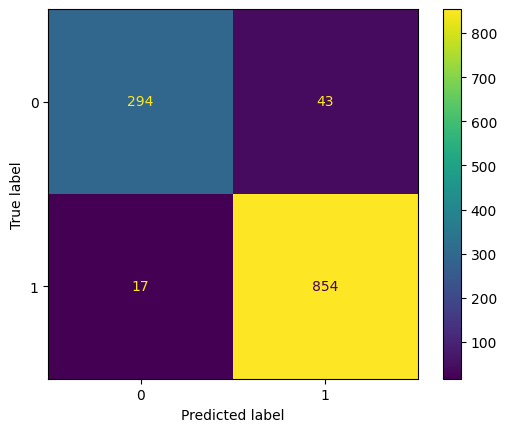

Valore finale di MCC:   0.87385
Altre metriche importanti
Accuratezza: 0.95033
Precisione:  0.95206
Recall:      0.98048
F1 score:    0.96606


In [16]:
# facciamo predizioni usando il threshold trovato precedentemente
probs = final_model_2.predict_proba(scaled_X_test)[:, 1]
preds = (probs >= best_thr).astype(int)

# matrice di confusione
metrics.ConfusionMatrixDisplay.from_predictions(y_test, preds, display_labels=final_model_2.classes_)
plt.show()

# calcolo dell'MCC finale (analogo ad E_out)
MCC_score = metrics.matthews_corrcoef(y_test, preds)
print(f'Valore finale di MCC:   {max_MCC_score:.5f}')

accuracy_score = metrics.accuracy_score(y_test, preds)
precision_score = metrics.precision_score(y_test, preds)
recall_score = metrics.recall_score(y_test, preds)
f1_score = metrics.f1_score(y_test, preds)

print('Altre metriche importanti')
print(f'Accuratezza: {accuracy_score:.5f}')
print(f'Precisione:  {precision_score:.5f}')
print(f'Recall:      {recall_score:.5f}')
print(f'F1 score:    {f1_score:.5f}')

In conclusione il nostro modello è buono (MCC = 0.874) sull'insieme di test. 

## Studio a 4 classi

Adesso ripetiamo lo studio svolto precedentemente ma senza ridurci ad un problema binario, in questo modo valutiamo se il nostro metodo rimane valido anche per allenare modelli più complessi. Chiaramente, aumentando il numero di classi, si riduce la quantità di dati per classe e anche gli alberi decisionali diventano più complessi e proni ad errori. Per questo motivo ci aspettiamo che il modello abbia una performance peggiore rispetto a quello allenato per il problema binario ma speriamo che rimanga comunque buono. Scegliamo tuttavia di accorpare le classi 'poor' e 'very poor' visto che la classe 'very poor' è decisamente ridotta rispetto alle altre e abbiamo verificato che questo impatta sensibilmente le capacità predittive del modello. Inoltre, poiché entrambe le classi si trovano al di sopra del limite consigliato, il comportamento da adottare in entrambe le situazioni è essenzialmente uguale e pertanto la distinzione è poco interessante.

In [17]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
four_class_df = pd.read_csv('../../data/processed/dataset_five_class_processed.csv')

# accorpiamo poor e very poor
four_class_df['target'] = four_class_df['target'].replace('very poor', 'poor')

# togliamo la colonna 'winds_spd'
four_class_df.drop('winds_spd', axis=1, inplace=True)

# escludiamo poi anche diverse righe contenenti NaN sulle rilevazioni degli inquinanti (probabilmente dovute a malfunzionamenti dei sensori)
four_class_df.dropna(inplace=True)

four_class_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,monday,tuesday,wednesday,...,NO2_2,AQI_2,power_area_50_2,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,target
0,1,0,0,0,0,0,0,0,0,0,...,17.0,22.0,14.669913,19.0,19.0,24.0,17.861264,10.950,0.0,fair
1,1,0,0,0,0,0,0,0,0,0,...,18.0,26.0,16.969367,20.0,17.0,22.0,14.669913,11.000,0.0,fair
2,1,0,0,0,0,0,0,0,0,0,...,16.0,26.0,15.329278,21.0,18.0,26.0,16.969367,10.925,0.0,fair
3,1,0,0,0,0,0,0,0,0,0,...,16.0,32.0,17.519438,19.0,16.0,26.0,15.329278,10.950,0.0,fair
4,1,0,0,0,0,0,0,0,0,0,...,15.0,22.0,17.446178,24.0,16.0,32.0,17.519438,11.550,0.0,fair


### Train, Test split

Poiché lavoriamo con un problema a 4 classi, viene meno la necessità di ottimizzare il threshold, pertanto, la nostra procedura varia leggermente. Dividiamo inizialmente in train (80%) e test (20%) e alleniamo il modello su trai, ottimizzato gli iperparametri con GridSearchCV. Valutiamo infine la performance del modello su test.

In [18]:
feature_cols = four_class_df.columns.difference(['target'])

# creiamo train, valid e test
X_train, X_test, y_train, y_test = train_test_split(four_class_df[feature_cols], four_class_df['target'], test_size=0.2, random_state=seed)

# riscaliamo le feature numeriche, mettendo la media a 0 e la deviazione std a 1
station_cols = [col for col in X_train.columns if col.startswith('station_')]
non_num_features = ['day', 'hour', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday'] + station_cols
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_test  = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_test  = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_test[num_features]  = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,AQI_3,NO2_1,NO2_2,NO2_3,PM10_1,PM10_2,PM10_3,day,...,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,sunday,temperature,thursday,tuesday,wednesday
1456,-0.788599,-0.775077,-0.752350,-1.194670,-1.159993,-1.125959,-1.084896,-1.036987,-1.040140,3,...,0,0,0,0,0,1,1.998874,0,0,0
4437,-0.997869,-1.042289,-1.043086,-0.591904,-0.657331,-0.591051,-0.534318,-0.585439,-0.586879,16,...,0,1,0,0,0,0,-0.088111,0,0,0
9215,1.569172,0.863048,0.026822,3.225615,3.062363,1.448285,2.268623,1.070238,0.319645,42,...,0,0,0,0,1,0,-0.623660,1,0,0
4721,-0.439817,-0.376195,-0.314308,-0.056112,-0.221691,-0.223302,0.016259,0.066797,0.118195,29,...,0,1,0,0,0,0,-2.528448,0,0,0
9485,1.172335,1.271998,1.273497,1.216395,1.621400,1.515149,1.317625,1.471614,1.477980,54,...,0,0,0,0,1,0,0.557860,0,1,0


### Allenamento modello

In [19]:
# creiamo una griglia di iperparametri
param_grid = {'n_estimators': [100, 200, 500],
                'max_depth': [5, 10, None],
                'min_samples_leaf': [1, 2, 5],
                'max_features': [None, 'sqrt', 'log2'],
                'class_weight': [None, 'balanced']}


# inizializziamo il classificatore
rfc_4 = GridSearchCV(RandomForestClassifier(random_state=seed),
                    param_grid,                                                   # iperparametri
                    scoring=metrics.make_scorer(metrics.matthews_corrcoef),       # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
                    cv=5,                                                         # numero di fold della cross validation
                    n_jobs=-1,                                                    # sfruttiamo al massimo la CPU
                    refit=True)                                                   # usiamo i parametri trovati per addestrare il modello su tutto train

In [20]:
# alleniamo e troviamo gli iperparametri migliori
rfc_4.fit(scaled_X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=12), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [5, 10, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5],
                         'n_estimators': [100, 200, 500]},
             scoring=make_scorer(matthews_corrcoef, response_method='predict'))

In [21]:
# diamo un'occhiata agli iperparametri migliori
print(rfc_4.best_params_)

{'class_weight': None, 'max_depth': None, 'max_features': None, 'min_samples_leaf': 5, 'n_estimators': 200}


Notiamo che gli iperparametri rimangono uguali a quelli ottenuti precedentemente per il problema binario.

In [22]:
rfc_4_best = rfc_4.best_estimator_

### Studio importanza features

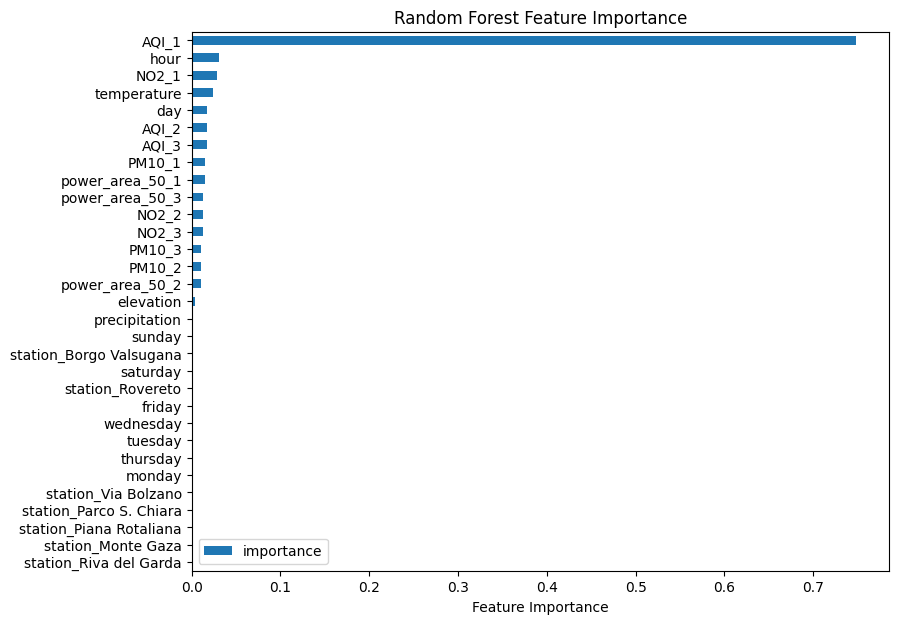

In [23]:
# quali feature sono più importanti?
classification_features = scaled_X_train.columns.difference(['target'])

df_importance_4 = pd.DataFrame({'importance': rfc_4_best.feature_importances_}, index=classification_features)

df_importance_4 = df_importance_4.sort_values(by='importance', ascending=True)

df_importance_4.plot.barh(figsize=(9,7))

plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

Vediamo che le importanze delle features esprimono la stessa tendenza vista precedentemente ma in modo ancora più marcato. L'indice di qualità dell'aria relativo all'ora precedente costituisce la quasi totalità del funzionamento del modello. È inoltre interessante notare che la temperatura gioca un ruolo più importante rispetto a quasi tutte le altre feature.

### Studio matrici di confusione

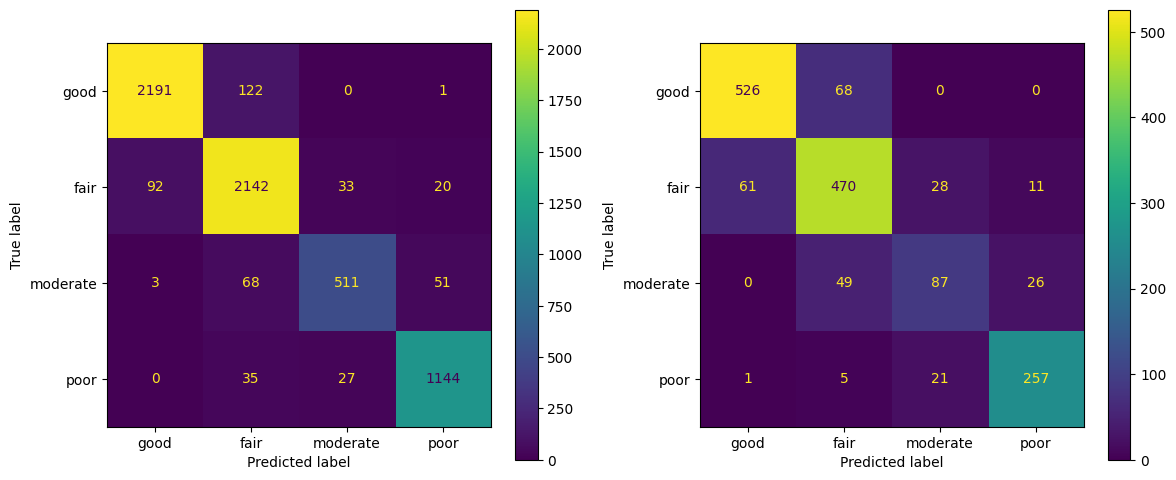

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_order = ['good', 'fair', 'moderate', 'poor']

y_pred_tr = rfc_4_best.predict(scaled_X_train)
metrics.ConfusionMatrixDisplay.from_predictions(y_train, y_pred_tr, labels=class_order, display_labels=class_order, ax = axes[0])

y_pred_te = rfc_4_best.predict(scaled_X_test)
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_te, labels=class_order, display_labels=class_order, ax = axes[1])

plt.tight_layout()
plt.show()

Il modello appare buono, con un leggero peggioramento su test che è completamente atteso. In ogni caso, il modello indovina la maggior parte delle previsioni e sembra buono. Misuriamo infine le misure di MCC, accuratezza, precision, recall e F1 su test in modo da valutare accuratamente la performance del nostr modello.

### Valutiamo infine la performance del modello su train

In [25]:
# calcolo dell'MCC finale (analogo ad E_out)
MCC_score = metrics.matthews_corrcoef(y_test, y_pred_te)
print(f'Valore finale di MCC:   {MCC_score:.5f}')

accuracy_score = metrics.accuracy_score(y_test, y_pred_te)
precision_score = metrics.precision_score(y_test, y_pred_te, average='macro')
recall_score = metrics.recall_score(y_test, y_pred_te, average='macro')
f1_score = metrics.f1_score(y_test, y_pred_te, average='macro')

print('Altre metriche importanti')
print(f'Accuratezza: {accuracy_score:.5f}')
print(f'Precisione:  {precision_score:.5f}')
print(f'Recall:      {recall_score:.5f}')
print(f'F1 score:    {f1_score:.5f}')

Valore finale di MCC:   0.75876
Altre metriche importanti
Accuratezza: 0.83230
Precisione:  0.80058
Recall:      0.78801
F1 score:    0.79303


Il modello è buono anche su valid e si conferma la nostra previsione di una riduzione della qualità del modello all'aumentare delle classi. Possiamo quindi ritenerci soddisfatti della procedura impiegata.

## Studio giornaliero

Dopo aver studiato le predizioni che siamo capaci di compiere ora per ora, ci concentriamo sul predire la qualità dell'aria di un dato giorno a partire dai dati relativi ai due giorni precedenti. Con le informazioni a nostra disposizione questo problema appare decisamente più difficile poiché, fissata una stazione, ad ogni giorno non corrispondono 24 punti bensì 1. Siccome abbiamo pochi dati, scegliamo di concentrarci sulla formulazione più semplice del problema, ovvero la classificazione in 2 sole classi.

In [26]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
daily_class_df = pd.read_csv('../../data/processed/dataset_day_class_processed.csv')

# escludiamo poi anche diverse righe contenenti NaN sulle rilevazioni degli inquinanti (probabilmente dovute a malfunzionamenti dei sensori)
daily_class_df.dropna(inplace=True)

daily_class_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Rovereto,station_Via Bolzano,PM10_1,NO2_1,AQI_1,power_area_50_1,PM10_2,NO2_2,AQI_2,power_area_50_2,temperature,precipitation,target
1,1,0,0,0,0,0,28.869565,21.086957,44.104348,18.197335,25.739130,18.913043,29.710145,17.843233,11.231522,0.013043,1
2,1,0,0,0,0,0,23.652174,18.826087,33.805797,17.478475,28.869565,21.086957,44.104348,18.197335,10.796739,0.126087,1
3,1,0,0,0,0,0,14.739130,26.739130,20.500000,37.200400,23.652174,18.826087,33.805797,17.478475,7.609783,0.028261,1
4,1,0,0,0,0,0,17.000000,25.913043,24.773913,37.421266,14.739130,26.739130,20.500000,37.200400,9.641304,0.000000,1
5,1,0,0,0,0,0,14.739130,26.956522,18.909420,35.957377,17.000000,25.913043,24.773913,37.421266,9.980435,0.000000,1


### Train, Valid, Test split

Ripetiamo pedissequamente la procedura impiegata per lo studio binario sulle ore. Pertanto il primo passo è nuovamente compiere uno split tra test (70%), valid(15%) e test (15%).

In [27]:
feature_cols = daily_class_df.columns.difference(['target'])

# creiamo train, valid e test
X_train, X_temp, y_train, y_temp = train_test_split(daily_class_df[feature_cols], daily_class_df['target'], test_size=0.3, random_state=seed)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

# riscaliamo le feature numeriche, mettendo la media a 0 e la deviazione std a 1
station_cols = [col for col in X_train.columns if col.startswith('station_')]
non_num_features = ['day', 'hour', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday'] + station_cols
num_features = X_train.columns.difference(non_num_features)

scaler = StandardScaler()
scaled_num_X_train = scaler.fit_transform(X_train[num_features])
scaled_num_X_valid = scaler.transform(X_valid[num_features])
scaled_num_X_test  = scaler.transform(X_test[num_features])

scaled_X_train = X_train.copy()
scaled_X_valid = X_valid.copy()
scaled_X_test  = X_test.copy()

scaled_X_train[num_features] = scaled_num_X_train
scaled_X_valid[num_features] = scaled_num_X_valid
scaled_X_test[num_features]  = scaled_num_X_test

scaled_X_train.head()

,AQI_1,AQI_2,NO2_1,NO2_2,PM10_1,PM10_2,power_area_50_1,power_area_50_2,precipitation,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Rovereto,station_Via Bolzano,temperature
87,-0.503631,-0.914142,-1.459298,-1.157780,-1.179947,-0.941733,-1.134687,-1.123800,-0.331115,0,1,0,0,0,0,0.360806
35,0.739947,1.394149,0.155155,0.637234,0.658594,1.866906,-0.238517,-0.223642,-0.331115,1,0,0,0,0,0,-0.333336
32,1.167177,1.139902,0.546022,0.606344,1.386729,1.445205,-0.228725,-0.260374,-0.331115,1,0,0,0,0,0,-1.332670
36,0.326502,0.766466,0.127964,0.196203,0.502565,0.680195,-0.573968,-0.228312,-0.331115,1,0,0,0,0,0,-0.461838
331,1.230671,0.104946,1.149803,0.788248,0.593582,0.015205,0.590117,0.717271,-0.331115,0,0,0,0,1,0,-0.765023


### Allenamento modello

In [28]:
# creiamo una griglia di iperparametri
param_grid = {'n_estimators': [100, 200, 500],
                'max_depth': [5, 10, None],
                'min_samples_leaf': [1, 2, 5],
                'max_features': [None, 'sqrt', 'log2'],
                'class_weight': [None, 'balanced']}


# inizializziamo il classificatore
rfc_d = GridSearchCV(RandomForestClassifier(random_state=seed),
                    param_grid,                                                   # iperparametri
                    scoring=metrics.make_scorer(metrics.matthews_corrcoef),       # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
                    cv=5,                                                         # numero di fold della cross validation
                    n_jobs=-1,                                                    # sfruttiamo al massimo la CPU
                    refit=True)                                                   # usiamo i parametri trovati per addestrare il modello su tutto train

In [29]:
# alleniamo e troviamo gli iperparametri migliori
rfc_d.fit(scaled_X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=12), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [5, 10, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5],
                         'n_estimators': [100, 200, 500]},
             scoring=make_scorer(matthews_corrcoef, response_method='predict'))

In [30]:
# diamo un'occhiata agli iperparametri migliori
print(rfc_d.best_params_)

{'class_weight': None, 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'n_estimators': 200}


In [31]:
rfc_d_best = rfc_d.best_estimator_

### Studio importanza features

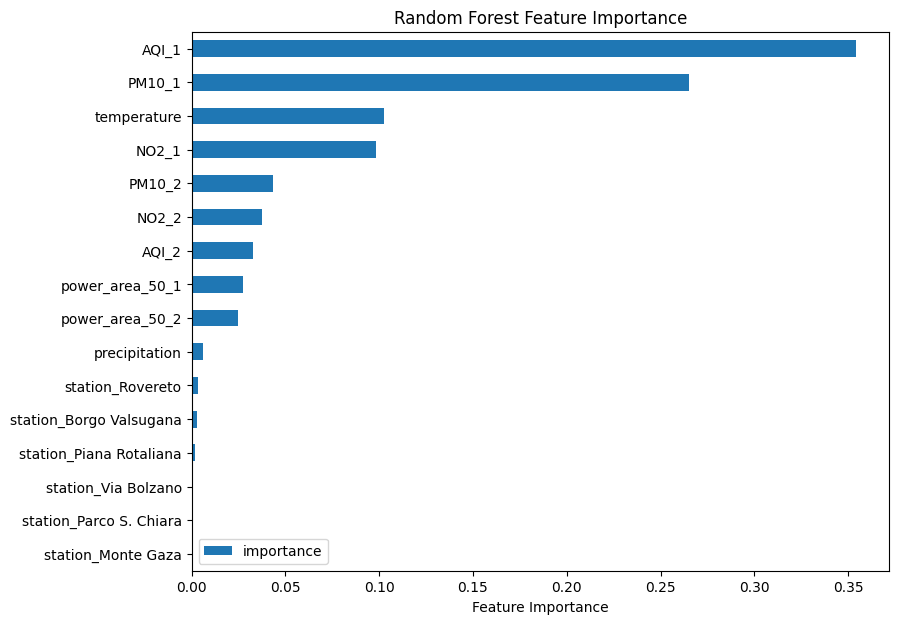

In [32]:
# quali feature sono più importanti?
classification_features = scaled_X_train.columns.difference(['target'])

df_importance_d = pd.DataFrame({'importance': rfc_d_best.feature_importances_}, index=classification_features)

df_importance_d = df_importance_d.sort_values(by='importance', ascending=True)

df_importance_d.plot.barh(figsize=(9,7))

plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()

Ancora una volta si conferma il trend visto per i due studi precedenti. La qualità dell'aria e le concentrazioni di inquinanti dei due giorni precedenti sono di gran lunga le feature più importanti mentre le stazioni APPA in cui i dati vengono raccolti sono essenzialmente insignificanti.

### Studio matrici di confusione

Vediamo se il training è stato efficace sui dati di train e ci chiediamo se il modello rimane buono anche su valid.

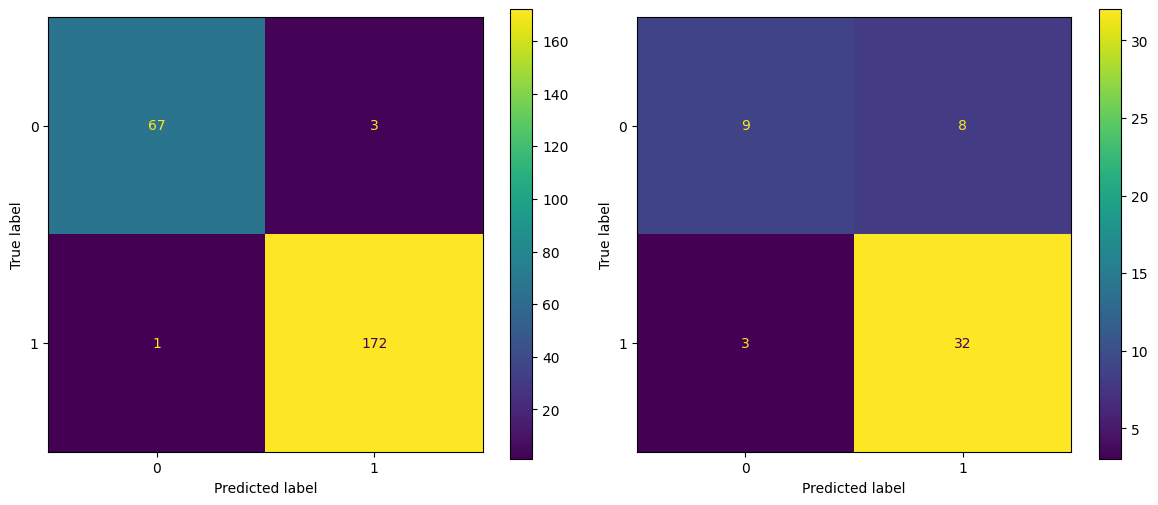

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_pred_tr = rfc_d_best.predict(scaled_X_train)
metrics.ConfusionMatrixDisplay.from_predictions(y_train, y_pred_tr, display_labels=rfc_d_best.classes_, ax = axes[0])

y_pred_va = rfc_d_best.predict(scaled_X_valid)
metrics.ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_va, display_labels=rfc_d_best.classes_, ax = axes[1])

plt.tight_layout()
plt.show()

Il modello funziona molto bene sui dati di train mentre peggiora in modo molto significativo sui dati di valid, infatti, vediamo che nel caso di target = 0 (cattiva qualità dell'aria) il modello classifica bene poco più di metà dei casi.

Vediamo che l'MCC peggiora significativamente in valid, arrivando ad un valore di 0.494 contro l'MCC ottenuto in train con GridSearchCV che è 0.960. Questo ci porta ad ipotizzare di star commettendo un forte overfitting. Tuttavia vediamo che l'area sotto la ROC nel caso di valid è ben 0.929. Questo ci comunica che il modello funziona bene anche su dati che non ha mai visto e, pertanto, ci suggerisce che non stiamo commettendo overfitting. Probabilmente il passaggio successivo, ovvero l'ottimizzazione del threshold, migliorerà drasticamente la situazione.

In [34]:
MCC_train = metrics.matthews_corrcoef(y_train, y_pred_tr)
MCC_valid = metrics.matthews_corrcoef(y_valid, y_pred_va)
y_proba_va = rfc_d_best.predict_proba(scaled_X_valid)[:, 1]
auc = metrics.roc_auc_score(y_valid, y_proba_va)

print(f'MCC su train:        {MCC_train}')
print(f'MCC su valid:        {MCC_valid}')
print(f'AUC di ROC su valid: {auc}')

MCC su train:        0.9597201746158784
MCC su valid:        0.4939975844529791
AUC di ROC su valid: 0.9294117647058823


### Ottimizzazione del threshold

Per i motivi espressi prima, in questo caso l'ottimizzazione del threshold appare più cruciale che mai.

In [35]:
y_proba_va = rfc_d_best.predict_proba(scaled_X_valid)[:, 1]

max_MCC_score = -1
best_thr = None

thr = np.linspace(0, 1, 1001)

for t in thr:
    y_pred = (y_proba_va >= t).astype(int)
    MCC_score = metrics.matthews_corrcoef(y_valid, y_pred)

    if (MCC_score > max_MCC_score):
        max_MCC_score = MCC_score
        best_thr = t


print(f'Threshold MCC: {best_thr:.5f}')
print(f'Massimo MCC:   {max_MCC_score:.5f}')

Threshold MCC: 0.69200
Massimo MCC:   0.84676


Effettivamente l'ottimizzazione del threshold a migliorato in modo molto significativo l'MCC su valid, scegliamo di dare una nuova occhiata alle matrici di confusione, in modo da capire se sono entrambe buone.

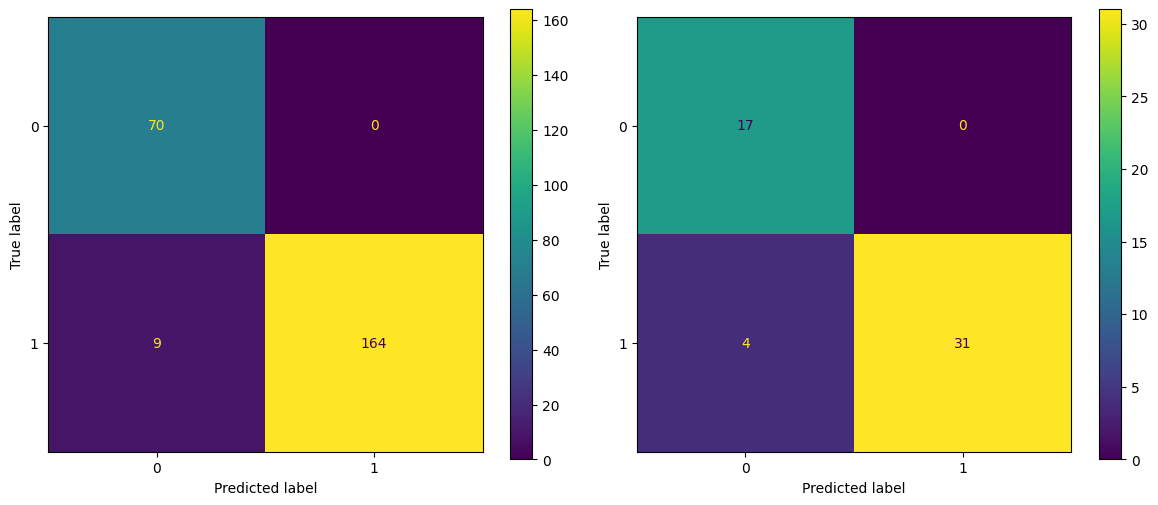

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_proba_tr = rfc_d_best.predict_proba(scaled_X_train)[:, 1]
y_pred_tr = (y_proba_tr >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(y_train, y_pred_tr, display_labels=rfc_d_best.classes_, ax = axes[0])

y_proba_va = rfc_d_best.predict_proba(scaled_X_valid)[:, 1]
y_pred_va = (y_proba_va >= best_thr).astype(int)
metrics.ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_va, display_labels=rfc_d_best.classes_, ax = axes[1])

plt.tight_layout()
plt.show()

La situazione è effettivamente migliorata drasticamente, il threshold sembra buono.

### Retrain su test + valid

In [37]:
# uniamo test e valid
merged_X = pd.concat([scaled_X_train, scaled_X_valid])
merged_y = pd.concat([y_train, y_valid])

In [38]:
final_model_d = RandomForestClassifier(**rfc_d.best_params_, random_state=seed)
final_model_d.fit(merged_X, merged_y)

RandomForestClassifier(max_depth=10, max_features=None, min_samples_leaf=2,
                       n_estimators=200, random_state=12)

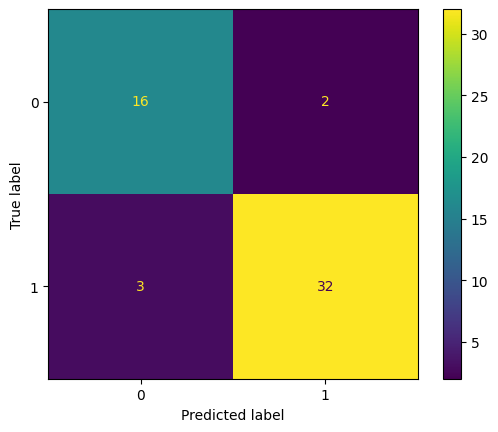

Valore finale di MCC:   0.84676
Altre metriche importanti
Accuratezza: 0.90566
Precisione:  0.94118
Recall:      0.91429
F1 score:    0.92754


In [39]:
# facciamo predizioni usando il threshold trovato precedentemente
probs = final_model_d.predict_proba(scaled_X_test)[:, 1]
preds = (probs >= best_thr).astype(int)

# matrice di confusione
metrics.ConfusionMatrixDisplay.from_predictions(y_test, preds, display_labels=final_model_d.classes_)
plt.show()

# calcolo dell'MCC finale (analogo ad E_out)
MCC_score = metrics.matthews_corrcoef(y_test, preds)
print(f'Valore finale di MCC:   {max_MCC_score:.5f}')

accuracy_score = metrics.accuracy_score(y_test, preds)
precision_score = metrics.precision_score(y_test, preds)
recall_score = metrics.recall_score(y_test, preds)
f1_score = metrics.f1_score(y_test, preds)

print('Altre metriche importanti')
print(f'Accuratezza: {accuracy_score:.5f}')
print(f'Precisione:  {precision_score:.5f}')
print(f'Recall:      {recall_score:.5f}')
print(f'F1 score:    {f1_score:.5f}')

Pertanto il modello finale è relativamente buono (MCC = 0.847) nelle predizioni nonostante la quantità limitata di dati. Chiaramente le predizioni prodotte usando questo approccio sono più utili dato che fanno riferimento al giorno successivo invece che all'ora successiva. D'altro canto, si perdono le informazioni più dettagliate sulle singole ore traendo un unico valore medio per tutta la giornata.

In conclusione, il modello funziona molto bene anche su test, con un valore finale di MCC pari a 0.847. Tutte le altre misure della qualità del modello sono sopra 0.9. Ci consideriamo perciò soddisfatti del risultato e dichiariamo conclusa questa indagine.